In [1]:
# make sure `src/` is on sys.path
import sys, os

# compute the absolute path to your `src/` directory
# assuming this notebook is in main/notebook/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
SRC_PATH     = os.path.join(PROJECT_ROOT, "src")

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

print("✅ src added to PYTHONPATH:", SRC_PATH)


✅ src added to PYTHONPATH: /home/kamiar/chevron/Acid-neural-net/main/src


In [2]:
import pandas as pd
import torch
import uuid
import os
from my_package import (
    cross_validate_mlp_with_history,
    make_tag,
    create_output_dir,
    save_models,
    save_hyperparams,
    save_norms,
    plot_diagnostics
)


In [3]:
# — change paths or params here as needed —
csv_path     = '../data/splited-first/train_val1.csv'
k_folds      = 7
layer_dims   = [4, 4]
activations  = ['softplus', 'softplus']
epochs       = 80
lr           = 1e-3
batch_size   = 8
random_state = 42
loss_type    = 'huber'   # or 'mse'
device       = 'cuda' if torch.cuda.is_available() else 'cpu'


In [4]:
df = pd.read_csv(csv_path)
df.head()


,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Input 9,Input 10,...,Input 12,Input 13,Input 14,Input 15,Input 16,Input 17,Input 18,Output,F2,F3
0,2,1,3,1,5,1,2,9,15,7.0,...,8.9,337,0.000900,47360,306.3,348.0,558.7,58045,4,3
1,2,1,3,1,5,2,1,6,13,48.0,...,201.6,17,0.000909,2319,15.1,16.5,1.5,-706,1,1
2,2,2,5,16,4,1,1,5,20,451.0,...,150.3,1514,0.000918,211636,1379.3,1513.9,208.7,40462,1,5
3,1,5,4,15,5,1,2,9,15,15.0,...,13.7,181,0.002369,17225,150.0,181.3,-10.4,3528,3,3
4,1,5,4,15,3,1,2,6,15,1041.0,...,30.0,131,0.001876,14230,114.0,190.8,58.5,10743,5,4


In [5]:
folds, histories, models, norms, feature_names = cross_validate_mlp_with_history(
    df,
    k_folds=k_folds,
    layer_dims=layer_dims,
    activations=activations,
    epochs=epochs,
    lr=lr,
    batch_size=batch_size,
    device=device,
    random_state=random_state,
    loss_type=loss_type
)


Fold 1 validation indices: [0, 4, 10, 11, 18, 36, 40, 45, 47, 66, 69, 70, 72, 81, 84, 100, 113]
Validation errors (pred-true): [-0.6083537340164185, 0.13013531267642975, 0.03767015039920807, 1.0691683292388916, 0.21449722349643707, 0.3000034689903259, 0.0551261305809021, -0.1882529854774475, 0.18623077869415283, 0.18661262094974518, -0.06180483102798462, -0.30574095249176025, 0.30497533082962036, 0.670082151889801, -0.006124436855316162, -0.47980958223342896, 0.9408928751945496]
Final losses (train, val): (0.0480, 0.1037)

Fold 2 validation indices: [12, 15, 22, 26, 30, 31, 44, 53, 67, 78, 83, 93, 94, 105, 108, 109, 112]
Validation errors (pred-true): [0.005159139633178711, -0.14085233211517334, 0.05510607361793518, 0.29497501254081726, 0.35096731781959534, -0.7067645788192749, -0.27661606669425964, 0.47429314255714417, -0.12695515155792236, -0.016630172729492188, 0.1404222548007965, -0.4706007242202759, -0.4334014356136322, -0.0016951113939285278, -0.08106151223182678, 0.0554317831993

In [6]:
tag = make_tag()
create_output_dir(tag)
tag


'c88c7e84'

In [7]:
# 1) models
save_models(models, tag)

# 2) hyperparameters
hp = {
    "csv_path":     csv_path,
    "k_folds":      k_folds,
    "layer_dims":   layer_dims,
    "activations":  activations,
    "epochs":       epochs,
    "lr":           lr,
    "batch_size":   batch_size,
    "random_state": random_state,
    "loss_type":    loss_type
}
save_hyperparams(hp, tag)

# 3) norms
save_norms(norms, tag)

print(f"Saved to ./{tag}/")


Saved to ./c88c7e84/


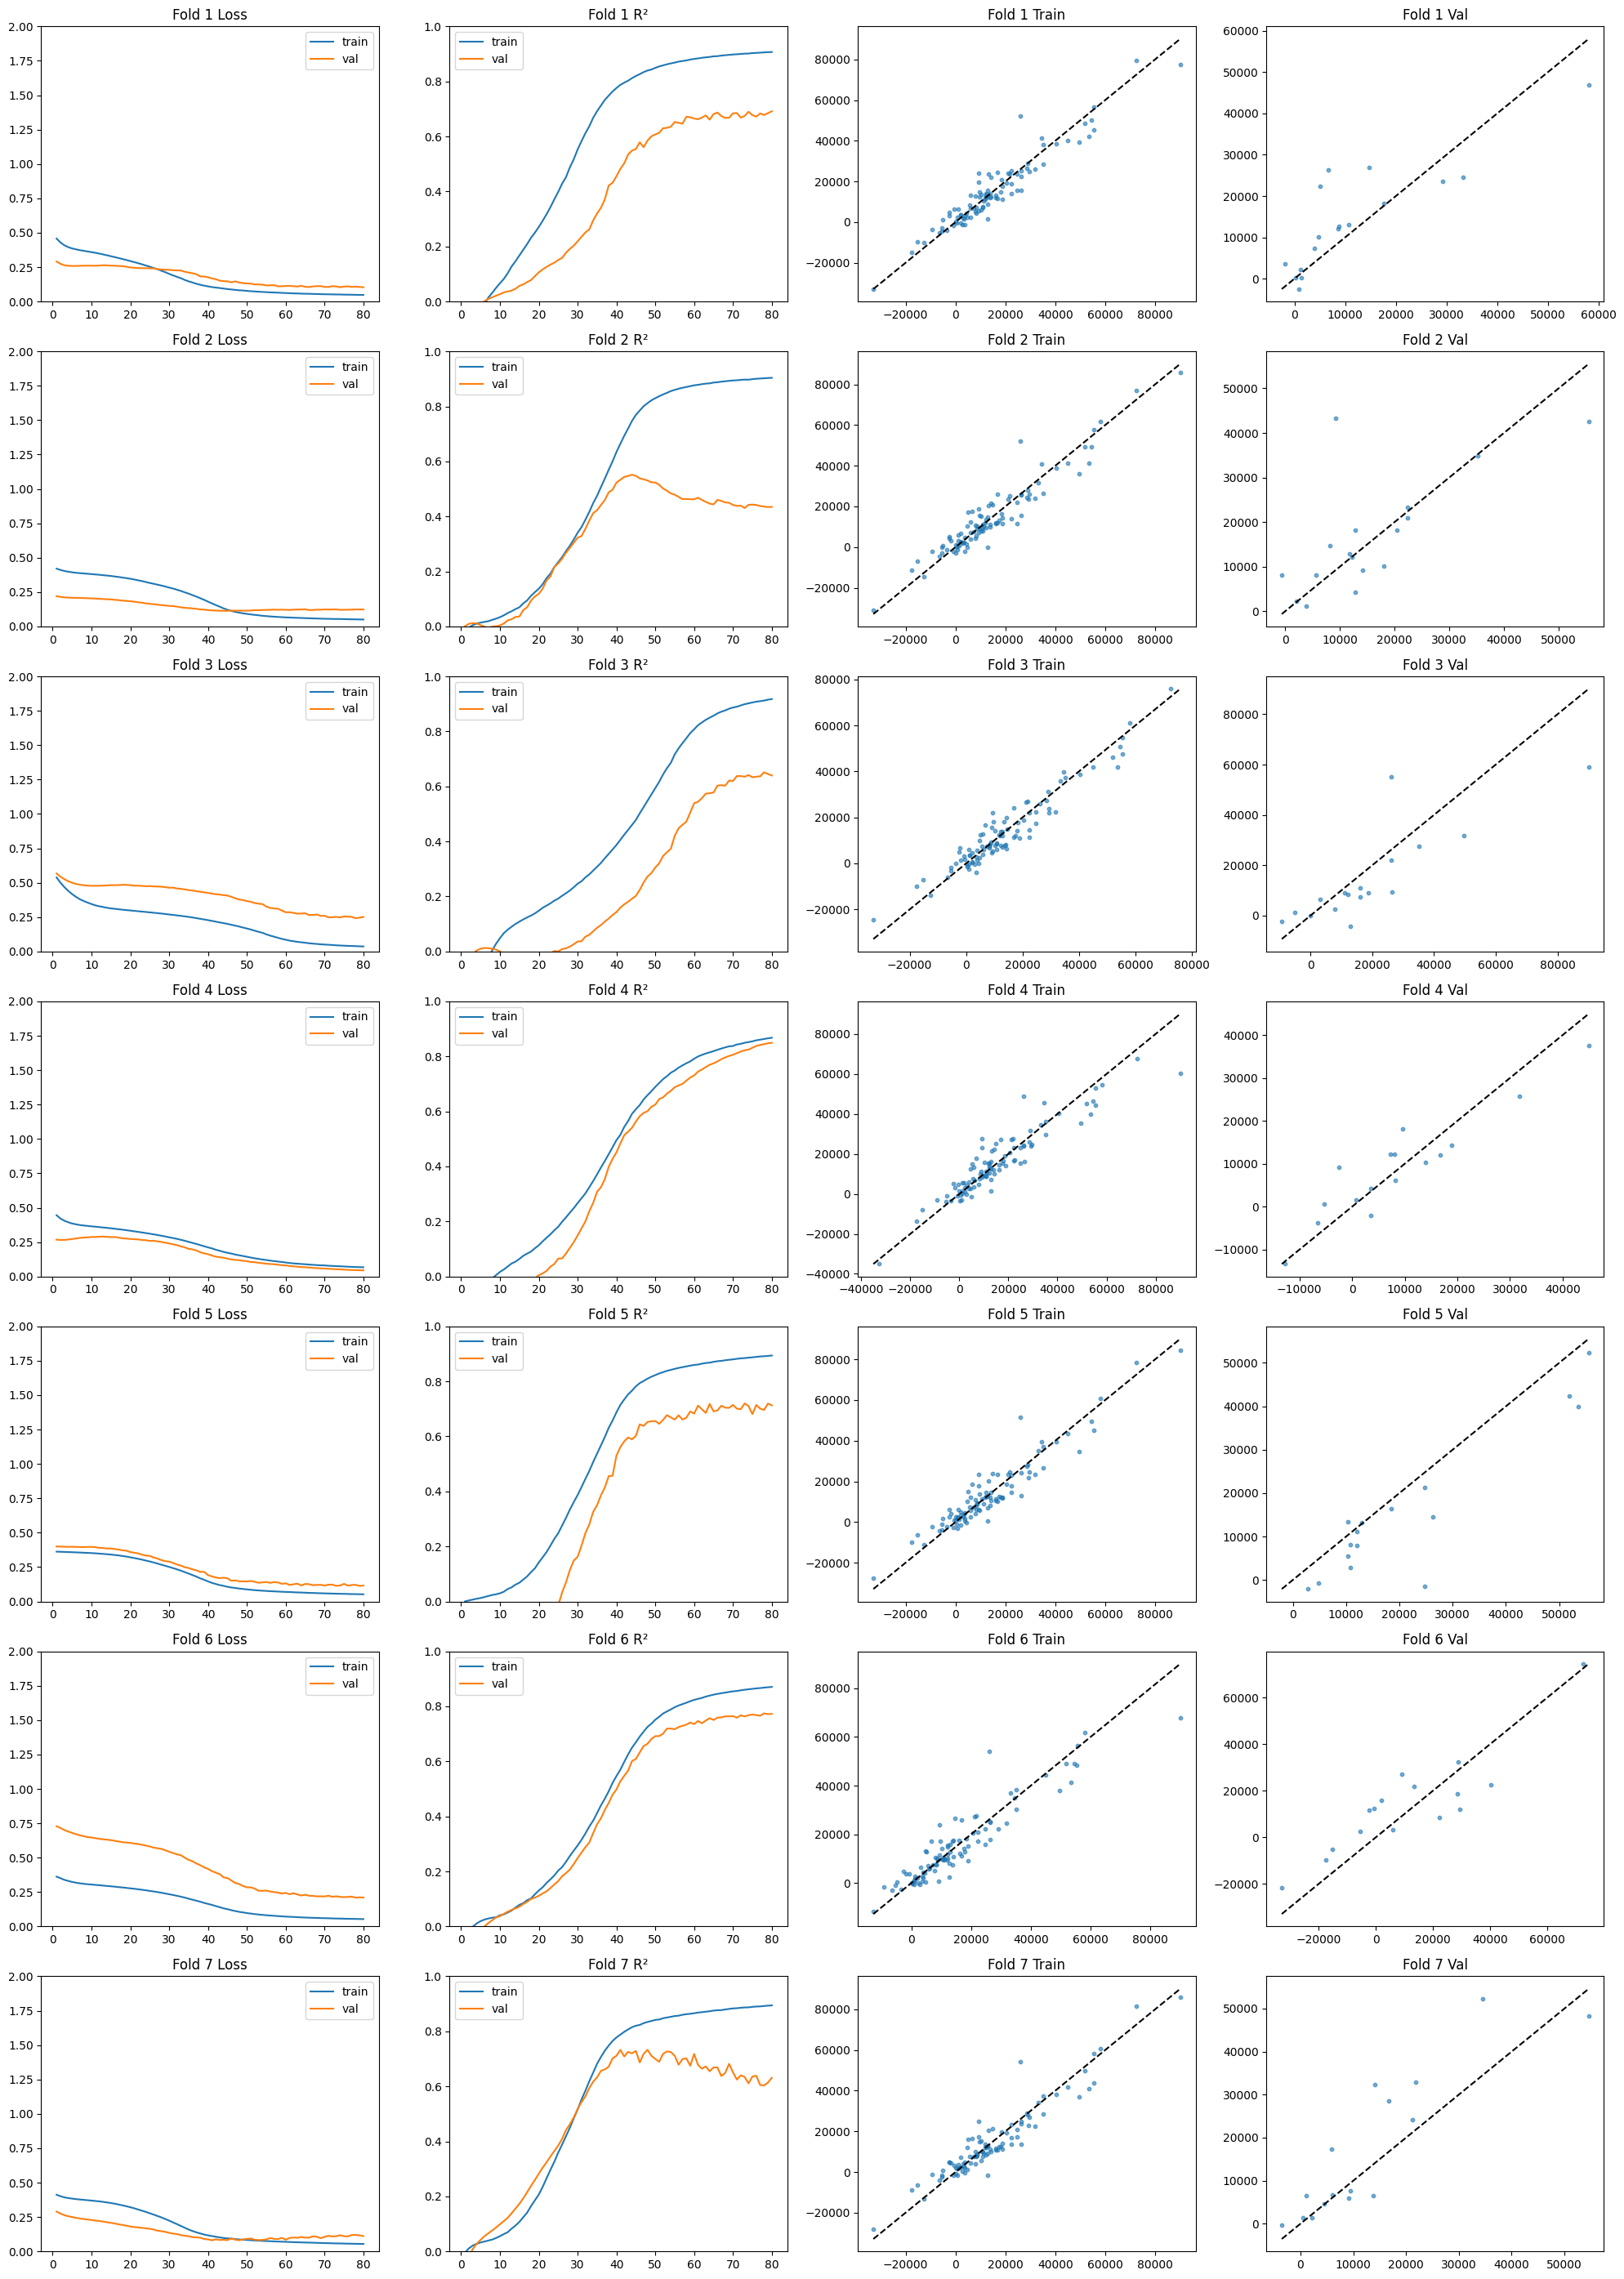

In [8]:
plot_diagnostics(
    folds, histories, norms,
    k_folds=k_folds,
    epochs=epochs,
    save_path=os.path.join(tag, f"{tag}_diagnostics.png"),
    show=True
)
